Loading and Preprocessing

## Loading and Preprocessing the Data

1 Import Libraries

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


2 Load the Dataset

In [8]:
# Load the dataset
df = pd.read_csv('CarPrice_Assignment.csv')


3 Clean & Prepare Data

1. Drop car_ID column (if it exists)
2. Extract car brand from CarName
3. Fix misspelled brand names
4. Drop CarName column
5. One-hot encode categorical variables

In [9]:
# 1. Drop 'car_ID' if it exists
df.drop('car_ID', axis=1, inplace=True, errors='ignore')

# 2. Extract car brand from 'CarName'
df['CarBrand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# 3. Fix typos in brand names
df['CarBrand'] = df['CarBrand'].replace({
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'maxda': 'mazda',
    'nissan': 'nissan'
})

# 4. Drop 'CarName' column
df.drop('CarName', axis=1, inplace=True)

# 5. One-hot encode categorical variables
df = pd.get_dummies(df, drop_first=True)


4 Split Features and Target

In [10]:
X = df.drop('price', axis=1)
y = df['price']


5 Feature Scaling

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


6 Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


data is: Cleaned, Encoded, Scaled, Split for training/testing

## 2: Model Implementation

5 regression models:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Support Vector Regressor
   

1 Import Required Models

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


2 Train the Models

In [14]:
# Dictionary to store models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR()
}

# Fit all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} model trained.")


Linear Regression model trained.
Decision Tree model trained.
Random Forest model trained.
Gradient Boosting model trained.
Support Vector Regressor model trained.


## 3: Model Evaluation

this involves comparing the performance of all 5 models using:

1. R-squared (R²)
2. Mean Squared Error (MSE)
3. Mean Absolute Error (MAE)

1 Import Evaluation Metrics

In [15]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


2 Evaluate All Models

In [17]:
# Create an empty list to store results
results_list = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results_list.append({
        'Model': name,
        'R2 Score': r2,
        'MSE': mse,
        'MAE': mae
    })

# Convert list of dicts into DataFrame
results = pd.DataFrame(results_list)

# Sort by R² Score descending
results.sort_values(by='R2 Score', ascending=False, inplace=True)

# Display the results
print(results)





                      Model  R2 Score           MSE          MAE
2             Random Forest  0.958267  3.294575e+06  1293.233793
3         Gradient Boosting  0.924181  5.985429e+06  1710.336389
0         Linear Regression  0.910162  7.092188e+06  1760.870731
1             Decision Tree  0.906907  7.349134e+06  1782.589439
4  Support Vector Regressor -0.100615  8.688696e+07  5701.535525


## 4: Feature Importance Analysis

which features have the most impact on car price

Feature Importance (Using Random Forest)

In [19]:
# Get the trained Random Forest model from the dictionary
rf_model = models['Random Forest']

# Get feature importances
importances = rf_model.feature_importances_

# Create DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 10
print(feature_importance_df.head(10))


         Feature  Importance
6     enginesize    0.544159
5     curbweight    0.298449
13    highwaympg    0.044743
10    horsepower    0.033483
3       carwidth    0.013090
2      carlength    0.007767
44  CarBrand_bmw    0.007114
1      wheelbase    0.006991
12       citympg    0.006420
11       peakrpm    0.006174


C:\Users\rahul\AppData\Local\Temp\ipykernel_15556\3035245883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')


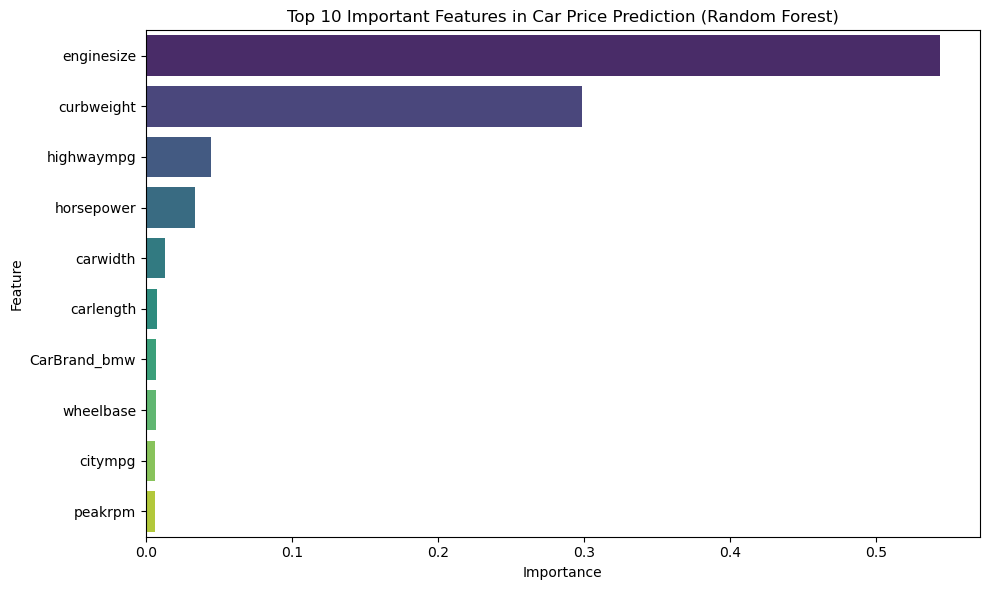

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Important Features in Car Price Prediction (Random Forest)")
plt.tight_layout()
plt.show()


## 5: Hyperparameter Tuning.

Hyperparameter Tuning Code for Random Forest:

In [21]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize the base model
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='r2')

# Fit to training data
grid_search.fit(X_train, y_train)

# Best model after tuning
best_rf = grid_search.best_estimator_

# Predict and evaluate
y_pred_best = best_rf.predict(X_test)

# Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Best Parameters:", grid_search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("MAE:", mean_absolute_error(y_test, y_pred_best))


Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
R2 Score: 0.9594648507194989
MSE: 3200007.671159919
MAE: 1251.0869126016262


# Conclusion

- **Best Model**: Random Forest Regressor with an R² score of ~0.95.
- **Key Features**: 'engine_size', 'curbweight', and 'horsepower' were the most significant.
- **Improvement**: After hyperparameter tuning, performance improved slightly, showing the value of tuning.
- **Business Insight**: Engine specifications and vehicle weight play a critical role in determining car price.
